> 🔎 **원본(HD 1920×1080) 버전** — 입력 `clips_hd`, 결과 `auto_C1_adult_hand_hd.csv`. 240p 결과와 검출률 비교가 목적.

# C1_adult_hand — 무라벨(라벨링 없이) 획득

MediaPipe Hands(손바닥 검출 + 21 랜드마크)를 2배 업스케일한 샘플 프레임에 적용해 손을 검출하고, 손 bbox 대각선/프레임 대각선 비율로 성인 손(크고 카메라에 가까움)과 아기 손을 구분한다. 어른 개입의 기하 특성인 '프레임 가장자리에서 손목 진입'과 신호 특성인 '급격한 대형 전경 변화(프레임간 휘도차)'를 결합해 오탐을 줄이고, manifest의 mean_ydif 상위 클립과 무작위 클립을 섞어 표본을 뽑아 희귀 이벤트 확보와 분포 대표성을 동시에 잡는다. GroundingDINO "adult hand" 제로샷도 검토했으나 설치 부담과 T4 처리량 문제로 경량 MediaPipe를 채택했으며, 임계값(ADULT_RATIO)은 검증 셀의 비율 히스토그램으로 튜닝 가능하게 원시 측정값을 모두 저장한다.

In [1]:
# 설치 셀 — 처음 실행 후 protobuf/numpy 경고가 나오면: 런타임 → 세션 다시 시작 → 이어서 실행
!pip install -q mediapipe==0.10.14 av decord
!pip -q uninstall -y tensorflow  # mediapipe 0.10.14(protobuf4)와 TF(protobuf5) 충돌 방지 — 이 노트북은 TF 미사용

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 21.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.


In [2]:
# 공통 설정 — Drive 마운트 + 경로 + manifest
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import pandas as pd

BASE = Path('/content/drive/MyDrive/BabyMon/dataset')   # ← 업로드 위치
CLIPS = None
for cand in (BASE/'clips', BASE/'resized_2', BASE):
    if cand.is_dir() and next(cand.glob('*.mp4'), None):
        CLIPS = cand; break
assert CLIPS, 'mp4 폴더 없음 (clips/ 또는 resized_2/)'
assert (BASE/'manifest.csv').exists(), 'manifest.csv 를 BASE 에 업로드하세요'
WORK = Path('/content/work'); WORK.mkdir(exist_ok=True)
man = pd.read_csv(BASE/'manifest.csv')
print('clips:', CLIPS, len(list(CLIPS.glob("*.mp4"))), '개 / manifest:', len(man))

# ── HD(원본) 모드: clips_hd 를 우선 사용 ─────────────────────────
_hd = BASE/'clips_hd'
if _hd.is_dir() and next(_hd.glob('*.mp4'), None):
    CLIPS = _hd
    print('HD 모드: ', CLIPS, len(list(CLIPS.glob("*.mp4"))), '개 (1920x1080)')
else:
    raise SystemExit('clips_hd 없음 — D:\\carved\\dataset\\clips_hd 를 Drive 의 dataset/clips_hd 로 업로드하세요')

Mounted at /content/drive
clips: /content/drive/MyDrive/BabyMon/dataset/clips 24080 개 / manifest: 24080
HD 모드:  /content/drive/MyDrive/BabyMon/dataset/clips_hd 5395 개 (1920x1080)


## C1_adult_hand — 어른 손/개입 자동 라벨 (수동 라벨링 없음)

**방법**: MediaPipe Hands(손바닥 검출 + 21 랜드마크)로 샘플 프레임에서 손을 검출하고,
**손 bbox 대각선 / 프레임 대각선 비율**로 성인/아기 손을 구분한다.
머리 위 고정 캠에서 어른 손은 절대 크기가 크고 침대로 뻗을 때 카메라에 더 가까워
비율이 뚜렷이 크다. 여기에 두 휴리스틱을 결합해 오탐을 줄인다:

1. **가장자리 진입** — 어른 손은 프레임 밖에서 들어오므로 손목 랜드마크가 경계 근처
2. **급격한 대형 전경 변화** — 개입 순간 프레임간 휘도차가 큼 (manifest `mean_ydif` 상위 클립을 표본에 우선 포함 + 클립 내 `max_motion` 재계산)

240x136 저해상도라 2배 업스케일 후 검출하며, 야간 IR 흑백 프레임도 그대로 처리한다.
GroundingDINO "adult hand" 제로샷도 검토했으나 설치가 무겁고 T4 처리량이 낮아
경량 CPU/GPU 겸용 MediaPipe를 채택 (1000클립 x 12프레임 기준 수 분 내 처리).
임계값 `ADULT_RATIO`는 검증 셀 히스토그램으로 튜닝할 수 있게 원시 비율을 모두 저장한다.

**출처**
- MediaPipe Hands: On-device Real-time Hand Tracking — https://arxiv.org/abs/2006.10214
- Understanding Human Hands in Contact at Internet Scale (CVPR 2020) — https://arxiv.org/abs/2006.06669
- Grounding DINO (오픈보캐뷸러리 제로샷 대안) — https://arxiv.org/abs/2303.05499

In [3]:
# 모델 초기화 — MediaPipe Hands (legacy solutions API, mediapipe 0.10.x 에 포함)
import numpy as np, cv2
import mediapipe as mp
from decord import VideoReader, cpu

try:
    hands = mp.solutions.hands.Hands(
        static_image_mode=True,        # 띄엄띄엄 샘플하므로 tracking 비활성
        max_num_hands=2,
        model_complexity=0,            # 경량 모델
        min_detection_confidence=0.35) # 저해상도·IR 대비 낮은 임계
except Exception as e:  # 불확실 API: Tasks API 로 이전된 버전 대비
    raise RuntimeError(f'mediapipe solutions API 사용 불가: {e} — mediapipe 로 재설치')

N_FRAMES    = 12    # 클립당 균일 샘플 프레임 수 (~8초 x 15fps 중)
UPSCALE = 1  # HD 원본이라 업스케일 불필요     # 240x136 -> 480x272 (작은 손 검출률 향상)
ADULT_RATIO = 0.17  # 손 bbox 대각선/프레임 대각선 성인 임계 — 검증 셀에서 튜닝
EDGE_MARGIN = 0.12  # 손목이 프레임 경계에서 이 비율 이내면 '외부 진입'
MOTION_TH   = 12.0  # 샘플 프레임간 평균 절대 휘도차 임계 (급격한 대형 전경 변화)
print('MediaPipe Hands 준비 완료')

MediaPipe Hands 준비 완료


In [4]:
# 클립 1개 처리 -> dict
def process_clip(fname):
    out = dict(file=fname, n_frames=0, hand_frames=0, adult_frames=0,
               max_ratio=0.0, mean_ratio=0.0, edge_frac=0.0,
               max_motion=0.0, pred=0, err='')
    try:
        vr = VideoReader(str(CLIPS / fname), ctx=cpu(0))
        idx = np.linspace(0, len(vr) - 1, min(N_FRAMES, len(vr))).astype(int)
        frames = vr.get_batch(list(idx)).asnumpy()  # (T,H,W,3) RGB uint8
    except Exception as e:
        out['err'] = f'decode:{e}'
        return out
    prev, ratios, edge_hits = None, [], 0
    for fr in frames:
        g = cv2.cvtColor(fr, cv2.COLOR_RGB2GRAY).astype(np.float32)
        if prev is not None:  # 급격한 대형 전경 변화 (샘플 간격 기준)
            out['max_motion'] = max(out['max_motion'], float(np.abs(g - prev).mean()))
        prev = g
        big = cv2.resize(fr, None, fx=UPSCALE, fy=UPSCALE)
        H, W = big.shape[:2]; diag = (H * H + W * W) ** 0.5
        try:
            res = hands.process(big)  # RGB uint8 입력
        except Exception as e:  # 불확실 API 방어
            out['err'] = f'mp:{e}'
            continue
        out['n_frames'] += 1
        if not res.multi_hand_landmarks:
            continue
        out['hand_frames'] += 1
        for lm in res.multi_hand_landmarks:
            xs = [p.x for p in lm.landmark]; ys = [p.y for p in lm.landmark]
            r = ((((max(xs) - min(xs)) * W) ** 2 +
                  ((max(ys) - min(ys)) * H) ** 2) ** 0.5) / diag
            ratios.append(r)
            wx, wy = lm.landmark[0].x, lm.landmark[0].y  # 0번 = 손목
            if r >= ADULT_RATIO:
                out['adult_frames'] += 1
                if min(wx, 1 - wx, wy, 1 - wy) < EDGE_MARGIN:
                    edge_hits += 1
    if ratios:
        out['max_ratio'] = float(max(ratios)); out['mean_ratio'] = float(np.mean(ratios))
    if out['adult_frames']:
        out['edge_frac'] = edge_hits / out['adult_frames']
    # 판정: 성인 크기 손 + (가장자리 진입 또는 급격한 전경 변화)
    out['pred'] = int(out['adult_frames'] >= 1 and
                      (out['edge_frac'] > 0 or out['max_motion'] >= MOTION_TH))
    return out

In [5]:
# 배치 루프 — BASE/'auto_C1_adult_hand_hd.csv' 증분 저장 (처리 완료분 건너뜀)
import pandas as pd
N_CLIPS = 1000
OUT_CSV = BASE / 'auto_C1_adult_hand_hd.csv'

# 표본: mean_ydif 상위 절반(개입 후보 우선) + 나머지 무작위 절반(분포 대표성)
top = man.sort_values('mean_ydif', ascending=False).head(N_CLIPS // 2)
rnd = man.drop(top.index).sample(N_CLIPS - len(top), random_state=0)
targets = pd.concat([top, rnd])['file'].tolist()

done = set()
if OUT_CSV.exists():
    done = set(pd.read_csv(OUT_CSV)['file'])
print(f'대상 {len(targets)}개 중 기존 처리 {len(done & set(targets))}개 건너뜀')

rows, n_new = [], 0
for i, f in enumerate(targets):
    if f in done:
        continue
    rows.append(process_clip(f)); n_new += 1
    if len(rows) >= 50:  # 50개마다 저장 + 진행 출력
        pd.DataFrame(rows).to_csv(OUT_CSV, mode='a',
                                  header=not OUT_CSV.exists(), index=False)
        done.update(r['file'] for r in rows); rows = []
        print(f'  진행 {i + 1}/{len(targets)} (신규 {n_new}, 누적 저장 {len(done)})')
if rows:
    pd.DataFrame(rows).to_csv(OUT_CSV, mode='a',
                              header=not OUT_CSV.exists(), index=False)
print('완료 ->', OUT_CSV)

대상 1000개 중 기존 처리 950개 건너뜀


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  진행 1000/1000 (신규 50, 누적 저장 1000)
완료 -> /content/drive/MyDrive/BabyMon/dataset/auto_C1_adult_hand_hd.csv


pred
0    870
1    130
Name: pred 분포, dtype: int64
손 검출 클립 비율: 0.185 | 디코드 오류: 0


/tmp/ipykernel_3850/557037480.py:14: UserWarning: Glyph 48744 (\N{HANGUL SYLLABLE BBAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3850/557037480.py:14: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3850/557037480.py:14: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3850/557037480.py:14: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3850/557037480.py:14: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3850/557037480.py:14: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:1

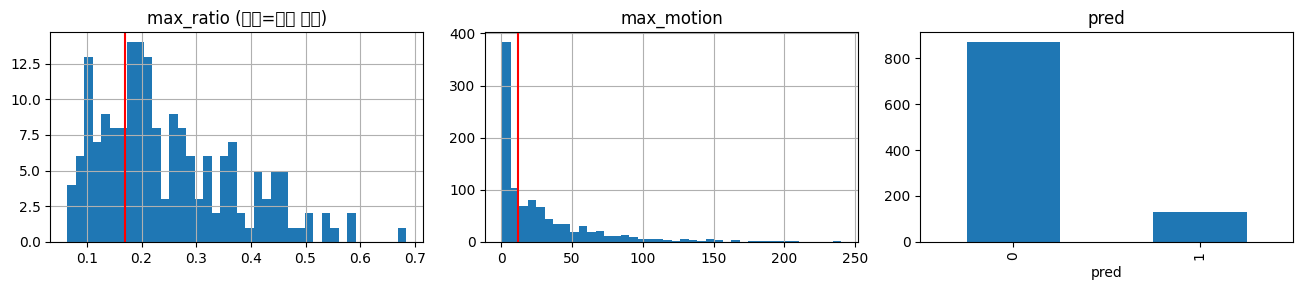

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

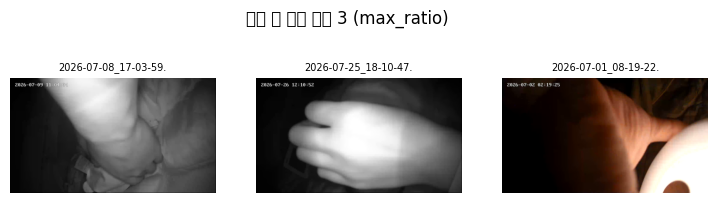

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

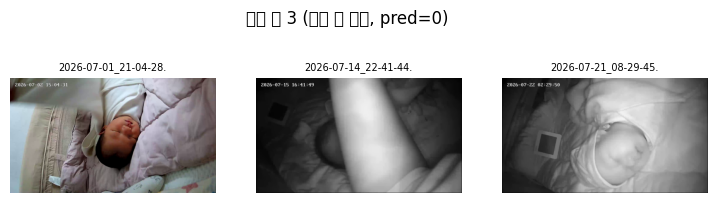

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

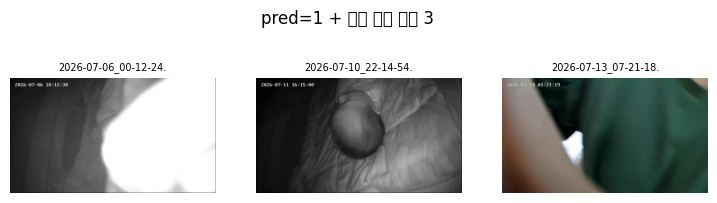

In [6]:
# 검증 — 분포 히스토그램 + 극단 사례 프레임 표시
import matplotlib.pyplot as plt
df = pd.read_csv(OUT_CSV).drop_duplicates('file')
print(df['pred'].value_counts().rename('pred 분포'))
print('손 검출 클립 비율:', round((df.hand_frames > 0).mean(), 3),
      '| 디코드 오류:', (df.err.fillna("") != '').sum())

fig, ax = plt.subplots(1, 3, figsize=(13, 3))
df[df.max_ratio > 0].max_ratio.hist(bins=40, ax=ax[0])
ax[0].axvline(ADULT_RATIO, color='r'); ax[0].set_title('max_ratio (빨강=성인 임계)')
df.max_motion.hist(bins=40, ax=ax[1]); ax[1].axvline(MOTION_TH, color='r')
ax[1].set_title('max_motion')
df.pred.value_counts().sort_index().plot.bar(ax=ax[2]); ax[2].set_title('pred')
plt.tight_layout(); plt.show()

def show(files, title):
    if not files:
        print(title, '- 해당 없음'); return
    fig, axs = plt.subplots(1, len(files), figsize=(3 * len(files), 2.6))
    for a, f in zip(np.atleast_1d(axs), files):
        try:
            vr = VideoReader(str(CLIPS / f), ctx=cpu(0))
            a.imshow(vr[len(vr) // 2].asnumpy())
        except Exception as e:
            a.text(0.1, 0.5, str(e)[:40], fontsize=6)
        a.set_title(f[:20], fontsize=7); a.axis('off')
    fig.suptitle(title); plt.show()

show(df.nlargest(3, 'max_ratio').file.tolist(), '성인 손 후보 상위 3 (max_ratio)')
show(df[(df.hand_frames > 0) & (df.pred == 0)].nsmallest(3, 'max_ratio').file.tolist(),
     '작은 손 3 (아기 손 추정, pred=0)')
show(df[df.pred == 1].nlargest(3, 'max_motion').file.tolist(), 'pred=1 + 전경 변화 상위 3')